**Primetrade.ai internship assignment**

**Trader Performance vs Market Sentiment (Fear & Greed) Analysis**

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Load Data**

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

**Understand the Data**

In [3]:
print(trades.head())
print(trades.info())
print(sentiment.head())
print(sentiment.info())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

**Rows and columns**

In [4]:
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


**Missing values**

In [5]:
print(trades.isnull().sum())
print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


**Clean Data**

**Trader Dataset**

In [32]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)
trades["Date"] = trades["Timestamp IST"].dt.date

**Sentiment Dataset**

In [33]:
sentiment = sentiment.rename(columns={
    "date":"Date",
    "classification":"Classification"
})
sentiment["Date"] = pd.to_datetime(sentiment["Date"]).dt.date

In [34]:
print(trades["Date"].head())
print(sentiment["Date"].head())

0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: Date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: Date, dtype: object


**Merge**

In [35]:
merged = pd.merge(
trades,
sentiment,
on="Date",
how="left"
)

In [36]:
print(merged.head())
print(merged["Classification"].value_counts(dropna=False))

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

**Winning Trade**

In [37]:
merged["Win"] = merged["Closed PnL"] > 0

**Daily PnL**

In [38]:
daily_pnl = merged.groupby(
["Account","Date"]
)["Closed PnL"].sum().reset_index()

**Win Rate**

In [39]:
win_rate = merged.groupby("Account")["Win"].mean()*100

**Average Trade Size**

In [40]:
avg_trade = merged.groupby("Account")["Size USD"].mean()

**Number of Trades**

In [41]:
trade_frequency = merged.groupby("Date").size()

**Long Short Ratio**

In [42]:
print(merged["Direction"].value_counts())

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


**Exploratory Data Analysis**

**Average PnL by Sentiment**

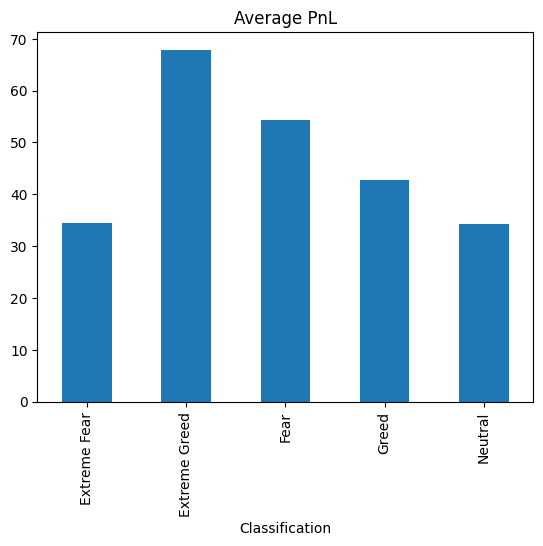

In [43]:
merged.groupby(
"Classification"
)["Closed PnL"].mean().plot(kind="bar")
plt.title("Average PnL")
plt.show()

**Number of Trades**

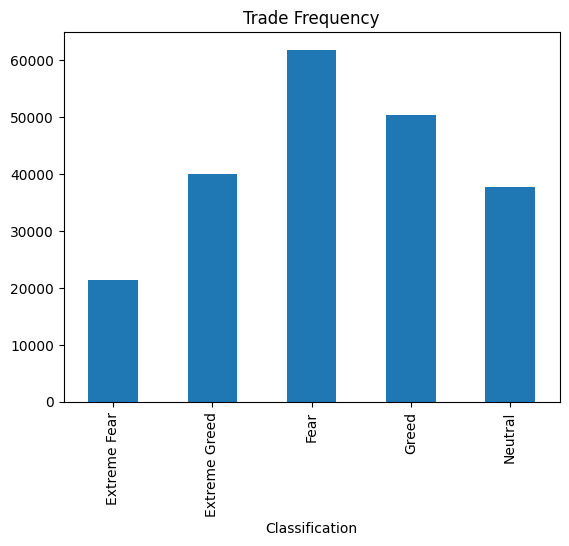

In [45]:
merged.groupby(
"Classification"
).size().plot(kind="bar")
plt.title("Trade Frequency")
plt.show()

**Long vs Short**

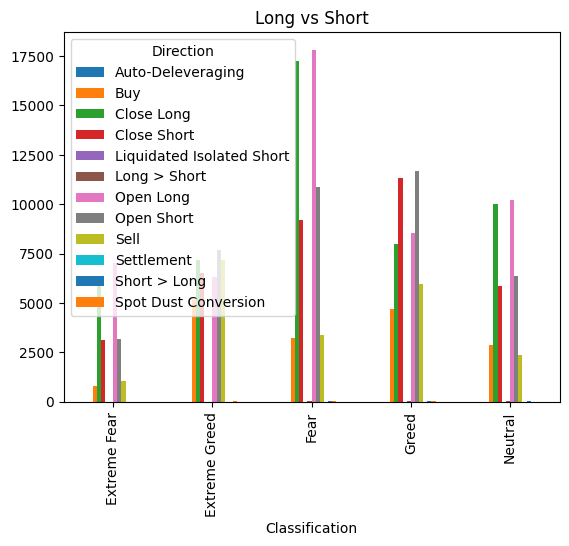

In [46]:
pd.crosstab(
merged["Classification"],
merged["Direction"]
).plot(kind="bar")
plt.title("Long vs Short")
plt.show()

**Position Size Distribution**

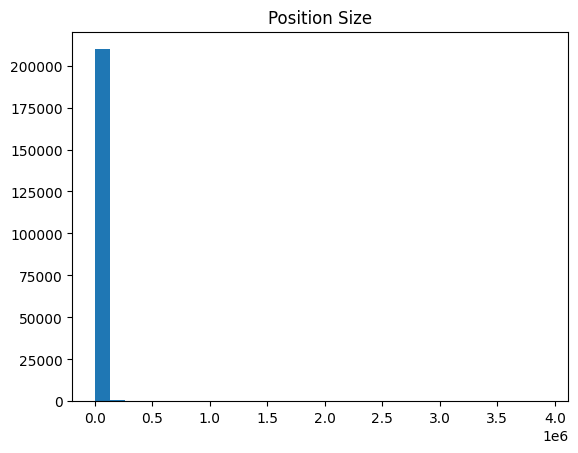

In [47]:
plt.hist(
merged["Size USD"],
bins=30
)
plt.title("Position Size")
plt.show()

**Closed PnL Distribution**

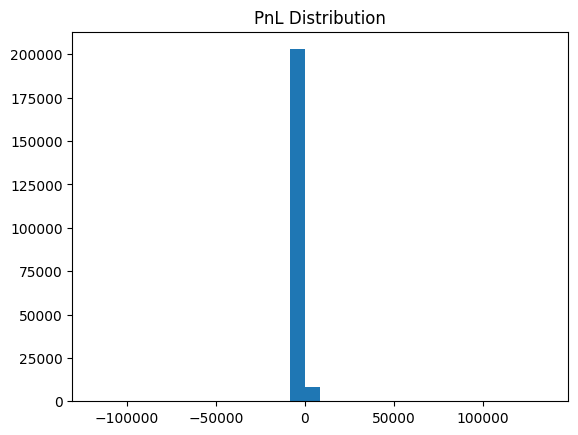

In [48]:
plt.hist(
merged["Closed PnL"],
bins=30
)
plt.title("PnL Distribution")
plt.show()

**Does performance differ?**

In [49]:
merged.groupby(
"Classification"
)[
"Closed PnL"
].agg(
["mean","median","sum"]
)

,mean,median,sum
Classification,,,
Extreme Fear,34.537862,0.0,7.391102e+05
Extreme Greed,67.892861,0.0,2.715171e+06
Fear,54.290400,0.0,3.357155e+06
Greed,42.743559,0.0,2.150129e+06
Neutral,34.307718,0.0,1.292921e+06


**Trade frequency**

In [50]:
merged.groupby(
"Classification"
).size()

Classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

**Average Position Size**

In [52]:
merged.groupby(
"Classification"
)["Size USD"].mean()

Classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

**Win Rate**

In [53]:
merged.groupby(
"Classification"
)["Win"].mean()*100

Classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

**Trader Segments**

**Frequent Traders**

In [54]:
segment1 = merged.groupby(
"Account"
).size().sort_values(
ascending=False
)

**Highest Profit**

In [55]:
segment2 = merged.groupby(
"Account"
)["Closed PnL"].sum().sort_values(
ascending=False
)

**Biggest Position Size**

In [28]:
segment3 = merged.groupby(
"Account"
)["Size USD"].mean().sort_values(
ascending=False
)